# **Tugas 3**

---


## CELL 1 — Install library

In [ ]:
%pip install pandas openpyxl Sastrawi gensim scikit-learn matplotlib seaborn

## CELL 2 — Import library

In [ ]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


## CELL 3 — Membaca dataset Excel

In [ ]:
file_path = "dataset_detik_200_berita.xlsx"

df = pd.read_excel(file_path)

print("Dataset berhasil dibaca.")
print("Ukuran dataset:", df.shape)

display(df.head())

Dataset berhasil dibaca.
Ukuran dataset: (200, 3)


,id,isi_berita,label
0,1,Pacuan kuda Indonesia mulai diarahkan menuju p...,sport
1,2,"Jelang Asian Games 2026, dukungan untuk 432 at...",sport
2,3,Nova Widianto mulai menangani tim ganda campur...,sport
3,4,Timnas basket putra Indonesia jadi rombongan p...,sport
4,5,"Bagi pelari urban, lari kini bukan lagi sekada...",sport


## CELL 4 — Mengecek dataset

In [ ]:
print("Jumlah baris :", len(df))
print("Jumlah kolom :", len(df.columns))

print("\nNama kolom:")
print(df.columns.tolist())

print("\nJumlah label:")
print(df["label"].value_counts())

print("\nData kosong:")
print(df.isnull().sum())

Jumlah baris : 200
Jumlah kolom : 3

Nama kolom:
['id', 'isi_berita', 'label']

Jumlah label:
label
sport      100
finance    100
Name: count, dtype: int64

Data kosong:
id            0
isi_berita    0
label         0
dtype: int64


## CELL 5 — Menghapus data kosong

In [ ]:
df = df.dropna(subset=["isi_berita", "label"])

print("Setelah menghapus data kosong:")
print("Jumlah data:", len(df))

print("\nData kosong:")
print(df[["isi_berita", "label"]].isnull().sum())

Setelah menghapus data kosong:
Jumlah data: 200

Data kosong:
isi_berita    0
label         0
dtype: int64


## CELL 6 — Case Folding

In [ ]:
df["case_folding"] = df["isi_berita"].str.lower()

print("SEBELUM:")
print(df["isi_berita"].iloc[0][:500])

print("\nSETELAH CASE FOLDING:")
print(df["case_folding"].iloc[0][:500])

SEBELUM:
Pacuan kuda Indonesia mulai diarahkan menuju panggung dunia melalui Indonesia's Horse Racing (IHR) 2026. Hal ini dikembangkan oleh Sarga.co dengan konsep olahraga, hiburan, pariwisata, dan ekonomi kreatif. IHR dikembangkan bukan hanya sebagai kompetisi untuk menentukan kuda tercepat. Platform tersebut dirancang menjadi bagian dari ekosistem yang menghubungkan olahraga berkuda dengan potensi daerah di berbagai wilayah Indonesia. Sarga.co hadir sebagai promotor pacuan kuda profesional pertama dan 

SETELAH CASE FOLDING:
pacuan kuda indonesia mulai diarahkan menuju panggung dunia melalui indonesia's horse racing (ihr) 2026. hal ini dikembangkan oleh sarga.co dengan konsep olahraga, hiburan, pariwisata, dan ekonomi kreatif. ihr dikembangkan bukan hanya sebagai kompetisi untuk menentukan kuda tercepat. platform tersebut dirancang menjadi bagian dari ekosistem yang menghubungkan olahraga berkuda dengan potensi daerah di berbagai wilayah indonesia. sarga.co hadir sebagai promotor pac

## CELL 7 — Menghapus tanda baca

In [ ]:
def hapus_tanda_baca(teks):
    return teks.translate(str.maketrans("", "", string.punctuation))

df["tanpa_tanda_baca"] = df["case_folding"].apply(hapus_tanda_baca)

print("SEBELUM:")
print(df["case_folding"].iloc[0][:500])

print("\nSETELAH MENGHAPUS TANDA BACA:")
print(df["tanpa_tanda_baca"].iloc[0][:500])

SEBELUM:
pacuan kuda indonesia mulai diarahkan menuju panggung dunia melalui indonesia's horse racing (ihr) 2026. hal ini dikembangkan oleh sarga.co dengan konsep olahraga, hiburan, pariwisata, dan ekonomi kreatif. ihr dikembangkan bukan hanya sebagai kompetisi untuk menentukan kuda tercepat. platform tersebut dirancang menjadi bagian dari ekosistem yang menghubungkan olahraga berkuda dengan potensi daerah di berbagai wilayah indonesia. sarga.co hadir sebagai promotor pacuan kuda profesional pertama dan 

SETELAH MENGHAPUS TANDA BACA:
pacuan kuda indonesia mulai diarahkan menuju panggung dunia melalui indonesias horse racing ihr 2026 hal ini dikembangkan oleh sargaco dengan konsep olahraga hiburan pariwisata dan ekonomi kreatif ihr dikembangkan bukan hanya sebagai kompetisi untuk menentukan kuda tercepat platform tersebut dirancang menjadi bagian dari ekosistem yang menghubungkan olahraga berkuda dengan potensi daerah di berbagai wilayah indonesia sargaco hadir sebagai promotor pacuan 

## CELL 8 — Menghapus angka

In [ ]:
def hapus_angka(teks):
    return re.sub(r"\d+", "", teks)

df["tanpa_angka"] = df["tanpa_tanda_baca"].apply(hapus_angka)

print("SEBELUM:")
print(df["tanpa_tanda_baca"].iloc[0][:500])

print("\nSETELAH MENGHAPUS ANGKA:")
print(df["tanpa_angka"].iloc[0][:500])

SEBELUM:
pacuan kuda indonesia mulai diarahkan menuju panggung dunia melalui indonesias horse racing ihr 2026 hal ini dikembangkan oleh sargaco dengan konsep olahraga hiburan pariwisata dan ekonomi kreatif ihr dikembangkan bukan hanya sebagai kompetisi untuk menentukan kuda tercepat platform tersebut dirancang menjadi bagian dari ekosistem yang menghubungkan olahraga berkuda dengan potensi daerah di berbagai wilayah indonesia sargaco hadir sebagai promotor pacuan kuda profesional pertama dan satusatunya 

SETELAH MENGHAPUS ANGKA:
pacuan kuda indonesia mulai diarahkan menuju panggung dunia melalui indonesias horse racing ihr  hal ini dikembangkan oleh sargaco dengan konsep olahraga hiburan pariwisata dan ekonomi kreatif ihr dikembangkan bukan hanya sebagai kompetisi untuk menentukan kuda tercepat platform tersebut dirancang menjadi bagian dari ekosistem yang menghubungkan olahraga berkuda dengan potensi daerah di berbagai wilayah indonesia sargaco hadir sebagai promotor pacuan kuda prof

## CELL 9 — Membersihkan spasi

In [ ]:
def bersihkan_spasi(teks):
    return re.sub(r"\s+", " ", teks).strip()

df["clean_text"] = df["tanpa_angka"].apply(bersihkan_spasi)

print(df["clean_text"].iloc[0][:500])

pacuan kuda indonesia mulai diarahkan menuju panggung dunia melalui indonesias horse racing ihr hal ini dikembangkan oleh sargaco dengan konsep olahraga hiburan pariwisata dan ekonomi kreatif ihr dikembangkan bukan hanya sebagai kompetisi untuk menentukan kuda tercepat platform tersebut dirancang menjadi bagian dari ekosistem yang menghubungkan olahraga berkuda dengan potensi daerah di berbagai wilayah indonesia sargaco hadir sebagai promotor pacuan kuda profesional pertama dan satusatunya di in


## CELL 10 — Tokenisasi

In [ ]:
df["tokens"] = df["clean_text"].apply(lambda x: x.split())

print("Teks:")
print(df["clean_text"].iloc[0][:300])

print("\nToken:")
print(df["tokens"].iloc[0][:30])

print("\nJumlah token:")
print(len(df["tokens"].iloc[0]))

Teks:
pacuan kuda indonesia mulai diarahkan menuju panggung dunia melalui indonesias horse racing ihr hal ini dikembangkan oleh sargaco dengan konsep olahraga hiburan pariwisata dan ekonomi kreatif ihr dikembangkan bukan hanya sebagai kompetisi untuk menentukan kuda tercepat platform tersebut dirancang me

Token:
['pacuan', 'kuda', 'indonesia', 'mulai', 'diarahkan', 'menuju', 'panggung', 'dunia', 'melalui', 'indonesias', 'horse', 'racing', 'ihr', 'hal', 'ini', 'dikembangkan', 'oleh', 'sargaco', 'dengan', 'konsep', 'olahraga', 'hiburan', 'pariwisata', 'dan', 'ekonomi', 'kreatif', 'ihr', 'dikembangkan', 'bukan', 'hanya']

Jumlah token:
377


## CELL 11 — Stopword

In [ ]:
factory_stopword = StopWordRemoverFactory()
stopwords = set(factory_stopword.get_stop_words())

print("Jumlah stopword:", len(stopwords))
print("\nContoh stopword:")
print(list(stopwords)[:30])

Jumlah stopword: 123

Contoh stopword:
['guna', 'serta', 'yaitu', 'bagi', 'ingin', 'sambil', 'kenapa', 'yang', 'mereka', 'ada', 'harus', 'terhadap', 'tidak', 'pula', 'kah', 'agak', 'kepada', 'anda', 'karena', 'lain', 'apakah', 'tanpa', 'sementara', 'telah', 'antara', 'walau', 'menurut', 'boleh', 'dahulu', 'dalam']


## CELL 12 — Menghapus Stopword

In [ ]:
def hapus_stopword(tokens):
    return [kata for kata in tokens if kata not in stopwords]

df["tokens_stopword"] = df["tokens"].apply(hapus_stopword)

print("SEBELUM STOPWORD:")
print(df["tokens"].iloc[0][:40])

print("\nSETELAH STOPWORD:")
print(df["tokens_stopword"].iloc[0][:40])

SEBELUM STOPWORD:
['pacuan', 'kuda', 'indonesia', 'mulai', 'diarahkan', 'menuju', 'panggung', 'dunia', 'melalui', 'indonesias', 'horse', 'racing', 'ihr', 'hal', 'ini', 'dikembangkan', 'oleh', 'sargaco', 'dengan', 'konsep', 'olahraga', 'hiburan', 'pariwisata', 'dan', 'ekonomi', 'kreatif', 'ihr', 'dikembangkan', 'bukan', 'hanya', 'sebagai', 'kompetisi', 'untuk', 'menentukan', 'kuda', 'tercepat', 'platform', 'tersebut', 'dirancang', 'menjadi']

SETELAH STOPWORD:
['pacuan', 'kuda', 'indonesia', 'mulai', 'diarahkan', 'menuju', 'panggung', 'dunia', 'melalui', 'indonesias', 'horse', 'racing', 'ihr', 'dikembangkan', 'sargaco', 'konsep', 'olahraga', 'hiburan', 'pariwisata', 'ekonomi', 'kreatif', 'ihr', 'dikembangkan', 'bukan', 'kompetisi', 'menentukan', 'kuda', 'tercepat', 'platform', 'tersebut', 'dirancang', 'menjadi', 'bagian', 'ekosistem', 'menghubungkan', 'olahraga', 'berkuda', 'potensi', 'daerah', 'berbagai']


## CELL 13 — Stemming

In [ ]:
factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()

print("Stemmer berhasil dibuat.")

Stemmer berhasil dibuat.


## CELL 14 — Melakukan Stemming

---


Kode pada cell 14 digunakan untuk **melakukan stemming**, yaitu mengubah kata menjadi bentuk kata dasarnya. Fungsi `stemming(tokens)` akan memproses setiap kata dalam daftar menggunakan `stemmer.stem(kata)`. Hasil stemming kemudian diterapkan pada seluruh data di kolom `tokens_stopword` dan disimpan ke kolom baru bernama `tokens_stemmed`. Bagian `print()` digunakan untuk membandingkan **40 kata pertama sebelum dan setelah stemming**, sehingga dapat dilihat perubahan kata setelah proses stemming dilakukan.



In [ ]:
def stemming(tokens):
    return [stemmer.stem(kata) for kata in tokens]

df["tokens_stemmed"] = df["tokens_stopword"].apply(stemming)

print("SEBELUM STEMMING:")
print(df["tokens_stopword"].iloc[0][:40])

print("\nSETELAH STEMMING:")
print(df["tokens_stemmed"].iloc[0][:40])

SEBELUM STEMMING:
['pacuan', 'kuda', 'indonesia', 'mulai', 'diarahkan', 'menuju', 'panggung', 'dunia', 'melalui', 'indonesias', 'horse', 'racing', 'ihr', 'dikembangkan', 'sargaco', 'konsep', 'olahraga', 'hiburan', 'pariwisata', 'ekonomi', 'kreatif', 'ihr', 'dikembangkan', 'bukan', 'kompetisi', 'menentukan', 'kuda', 'tercepat', 'platform', 'tersebut', 'dirancang', 'menjadi', 'bagian', 'ekosistem', 'menghubungkan', 'olahraga', 'berkuda', 'potensi', 'daerah', 'berbagai']

SETELAH STEMMING:
['pacu', 'kuda', 'indonesia', 'mulai', 'arah', 'tuju', 'panggung', 'dunia', 'lalu', 'indonesias', 'horse', 'racing', 'ihr', 'kembang', 'sargaco', 'konsep', 'olahraga', 'hibur', 'pariwisata', 'ekonomi', 'kreatif', 'ihr', 'kembang', 'bukan', 'kompetisi', 'tentu', 'kuda', 'cepat', 'platform', 'sebut', 'rancang', 'jadi', 'bagi', 'ekosistem', 'hubung', 'olahraga', 'kuda', 'potensi', 'daerah', 'bagai']


## CELL 15 — Menghitung jumlah kata unik SEBELUM preprocessing

In [ ]:
kata_sebelum = []

for tokens in df["tokens"]:
    kata_sebelum.extend(tokens)

unik_sebelum = set(kata_sebelum)

print("Total kata:", len(kata_sebelum))
print("Jumlah kata unik:", len(unik_sebelum))

Total kata: 60185
Jumlah kata unik: 7222


## CELL 16 — Menghitung jumlah kata unik SETELAH preprocessing

In [ ]:
kata_sesudah = []

for tokens in df["tokens_stemmed"]:
    kata_sesudah.extend(tokens)

unik_sesudah = set(kata_sesudah)

print("Total kata:", len(kata_sesudah))
print("Jumlah kata unik:", len(unik_sesudah))

print("\nPengurangan kata unik:")
print(len(unik_sebelum) - len(unik_sesudah))

Total kata: 45402
Jumlah kata unik: 5183

Pengurangan kata unik:
2039


## CELL 17 — Melihat hasil preprocessing

In [ ]:
df[[
    "isi_berita",
    "case_folding",
    "tanpa_tanda_baca",
    "tanpa_angka",
    "tokens_stopword",
    "tokens_stemmed",
    "label"
]].head(3)

,isi_berita,case_folding,tanpa_tanda_baca,tanpa_angka,tokens_stopword,tokens_stemmed,label
0,Pacuan kuda Indonesia mulai diarahkan menuju p...,pacuan kuda indonesia mulai diarahkan menuju p...,pacuan kuda indonesia mulai diarahkan menuju p...,pacuan kuda indonesia mulai diarahkan menuju p...,"[pacuan, kuda, indonesia, mulai, diarahkan, me...","[pacu, kuda, indonesia, mulai, arah, tuju, pan...",sport
1,"Jelang Asian Games 2026, dukungan untuk 432 at...","jelang asian games 2026, dukungan untuk 432 at...",jelang asian games 2026 dukungan untuk 432 atl...,jelang asian games dukungan untuk atlet indo...,"[jelang, asian, games, dukungan, atlet, indone...","[jelang, asi, games, dukung, atlet, indonesia,...",sport
2,Nova Widianto mulai menangani tim ganda campur...,nova widianto mulai menangani tim ganda campur...,nova widianto mulai menangani tim ganda campur...,nova widianto mulai menangani tim ganda campur...,"[nova, widianto, mulai, menangani, tim, ganda,...","[nova, widianto, mulai, tangan, tim, ganda, ca...",sport


## CELL 18 — Membuat corpus untuk Word2Vec

---


Kode ini digunakan untuk **membentuk corpus**, yaitu kumpulan dokumen yang akan digunakan pada proses analisis teks selanjutnya. Data pada kolom `tokens_stemmed` diubah menjadi bentuk list menggunakan `tolist()` dan disimpan dalam variabel `corpus`. Kemudian, `len(corpus)` digunakan untuk mengetahui **jumlah dokumen** yang terdapat dalam corpus. Sementara itu, `corpus[0][:50]` digunakan untuk menampilkan **50 token pertama dari dokumen pertama** sebagai pengecekan terhadap hasil stemming sebelum data digunakan pada tahap pemrosesan teks berikutnya.


In [ ]:
corpus = df["tokens_stemmed"].tolist()

print("Jumlah dokumen:", len(corpus))
print("\nDokumen pertama:")
print(corpus[0][:50])

Jumlah dokumen: 200

Dokumen pertama:
['pacu', 'kuda', 'indonesia', 'mulai', 'arah', 'tuju', 'panggung', 'dunia', 'lalu', 'indonesias', 'horse', 'racing', 'ihr', 'kembang', 'sargaco', 'konsep', 'olahraga', 'hibur', 'pariwisata', 'ekonomi', 'kreatif', 'ihr', 'kembang', 'bukan', 'kompetisi', 'tentu', 'kuda', 'cepat', 'platform', 'sebut', 'rancang', 'jadi', 'bagi', 'ekosistem', 'hubung', 'olahraga', 'kuda', 'potensi', 'daerah', 'bagai', 'wilayah', 'indonesia', 'sargaco', 'hadir', 'promotor', 'pacu', 'kuda', 'profesional', 'pertama', 'satusatunya']


## CELL 19 — Word2Vec Skip-Gram

---


Output tersebut menunjukkan bahwa **model Word2Vec dengan metode Skip-Gram berhasil dibuat dan dilatih menggunakan corpus yang telah melalui proses preprocessing dan stemming**. Model menggunakan `vector size` sebesar 100, sehingga setiap kata direpresentasikan dalam bentuk vektor yang memiliki 100 dimensi. Nilai `window` sebesar 5 berarti model mempertimbangkan hingga 5 kata di sekitar kata target untuk mempelajari hubungan antar kata. `Min count` sebesar 1 menunjukkan bahwa kata yang muncul minimal satu kali tetap dimasukkan ke dalam vocabulary, sedangkan proses pembelajaran dilakukan sebanyak 20 epoch. Hasilnya, model memiliki **5.183 kata dalam vocabulary**, yang berarti terdapat 5.183 kata unik yang berhasil dipelajari dan direpresentasikan oleh model Word2Vec.


In [ ]:
vector_size = 100
window = 5
min_count = 1
epochs = 20

model_w2v = Word2Vec(
    sentences=corpus,
    vector_size=vector_size,
    window=window,
    min_count=min_count,
    sg=1,          # 1 = Skip-Gram
    workers=4,
    epochs=epochs,
    seed=42
)

print("Word2Vec Skip-Gram berhasil dibuat.")
print("Vector size :", vector_size)
print("Window      :", window)
print("Min count   :", min_count)
print("Epoch       :", epochs)
print("Vocabulary  :", len(model_w2v.wv))

Word2Vec Skip-Gram berhasil dibuat.
Vector size : 100
Window      : 5
Min count   : 1
Epoch       : 20
Vocabulary  : 5183


## CELL 20 — Melihat vector sebuah kata

---

Kode ini digunakan untuk **mengambil dan melihat representasi vektor dari sebuah kata yang telah dipelajari oleh model Word2Vec**. Pada kode tersebut, kata yang ingin diperiksa adalah `"motogp"`. Kondisi `if kata in model_w2v.wv` digunakan untuk mengecek apakah kata tersebut terdapat di dalam vocabulary model. Jika ditemukan, `model_w2v.wv[kata]` akan menampilkan **vektor numerik yang dimiliki oleh kata tersebut**, sedangkan `len(model_w2v.wv[kata])` digunakan untuk mengetahui panjang atau jumlah dimensi vektor. Jika kata tidak terdapat dalam vocabulary, program akan menampilkan pesan `"Kata tidak ditemukan."`.

### **Penjelasan Output:**

Output menunjukkan bahwa kata **`motogp` berhasil ditemukan** di dalam vocabulary Word2Vec. Model kemudian menghasilkan sebuah vektor yang terdiri dari **100 nilai numerik**, misalnya `0.12987663`, `0.20204523`, `-0.01810063`, dan seterusnya. Nilai-nilai tersebut merupakan representasi numerik kata **`motogp`** yang dipelajari oleh model berdasarkan konteks kemunculan kata tersebut di dalam corpus. Hasil `Panjang vector: 100` menunjukkan bahwa sesuai dengan pengaturan sebelumnya, yaitu `vector_size = 100`, kata `motogp` direpresentasikan menggunakan **100 dimensi**. Vektor ini nantinya dapat digunakan untuk mencari kata-kata yang memiliki hubungan atau kemiripan konteks dengan `motogp`.



In [ ]:
kata = "motogp"

if kata in model_w2v.wv:
    print("Vector untuk kata:", kata)
    print(model_w2v.wv[kata])
    print("\nPanjang vector:", len(model_w2v.wv[kata]))
else:
    print("Kata tidak ditemukan.")

Vector untuk kata: motogp
[ 0.12987663  0.20204523 -0.01810063  0.34118518 -0.04646378 -0.13153054
 -0.5163383  -0.02534007  0.12251045  0.3054815  -0.6464835   0.79982024
  0.05889062  0.21911086 -0.10115279 -0.23891054  0.2411715   0.24887869
 -0.7914699  -0.64193445  0.04097204  0.48020843  0.31789654 -0.05044201
 -0.07246056  0.55716425 -0.34833905  0.7385978   0.22641577 -0.6799594
  0.08436118  0.19347925  0.3717668   0.09915899 -0.1942229  -0.98071873
 -0.46340564 -0.13180684  0.15841894  0.13454029  0.8830492  -0.25208688
  0.96068823 -0.31217635  0.6254426  -0.09926704  0.2590737   0.28979498
  0.5282581  -0.48963368 -0.05664426 -0.9937355  -0.32158142 -0.55076337
 -0.7532661   0.39832675 -0.24647708  0.21818766  0.5822659   0.13660572
 -0.54377514  0.8005877  -0.3070519   0.04997303 -0.02611538 -0.24831519
 -0.0615143  -0.3645011   0.01875832  0.20366545 -0.80818105  0.52085996
  0.3690165  -0.18630409 -0.41036776 -0.31096435 -0.07584697  0.12016116
 -0.00641245 -0.1790469   

## CELL 21 — Melihat kata yang mirip

---


Kode ini digunakan untuk **mencari kata-kata yang memiliki kemiripan konteks dengan kata `"balap"` berdasarkan model Word2Vec Skip-Gram yang telah dibuat**. Kondisi `if kata in model_w2v.wv` terlebih dahulu mengecek apakah kata `"balap"` terdapat dalam vocabulary model. Jika ditemukan, fungsi `most_similar(kata, topn=10)` akan mencari **10 kata yang memiliki vektor paling mirip dengan kata `"balap"`** berdasarkan nilai cosine similarity. Semakin mendekati nilai **1**, berarti semakin tinggi tingkat kemiripan vektor antara kata tersebut dengan kata `"balap"`.

### **Penjelasan Output:**

Hasil menunjukkan bahwa kata yang memiliki kemiripan paling tinggi dengan **`balap`** adalah **`buruk`** dengan nilai kemiripan `0.8129`, kemudian `sirkuit` (`0.7973`), `prix` (`0.7950`), `silverstone` (`0.7921`), dan seterusnya hingga 10 kata. Nilai tersebut menunjukkan **tingkat kedekatan berdasarkan pola penggunaan kata dalam corpus**, bukan berarti kata-kata tersebut memiliki arti yang sama. Misalnya, `sirkuit`, `prix`, `silverstone`, `misano`, dan `cedera` memiliki hubungan konteks dengan topik balap karena kemungkinan sering muncul dalam dokumen yang membahas balapan atau MotoGP. Sementara itu, kemunculan kata seperti `buruk` atau `puas` menunjukkan bahwa model mempelajari hubungan berdasarkan **konteks kata di dalam dataset**, sehingga hasil kemiripan sangat bergantung pada isi dan kualitas corpus yang digunakan.


In [ ]:
kata = "balap"

if kata in model_w2v.wv:
    print("Kata yang paling mirip dengan:", kata)
    print(model_w2v.wv.most_similar(kata, topn=10))
else:
    print("Kata tidak ditemukan.")

Kata yang paling mirip dengan: balap
[('buruk', 0.8128678202629089), ('sirkuit', 0.7972516417503357), ('prix', 0.7949512004852295), ('silverstone', 0.7920886278152466), ('grip', 0.7834540009498596), ('puas', 0.7824991345405579), ('sirkuitsirkuit', 0.7786701321601868), ('belanda', 0.7747467160224915), ('misano', 0.7738851308822632), ('cedera', 0.7715902924537659)]


## CELL 22 — Mengubah setiap berita menjadi vector

---


Kode ini digunakan untuk **mengubah setiap dokumen dalam dataset menjadi satu vektor numerik menggunakan hasil model Word2Vec**. Fungsi `document_vector()` mengambil vektor dari setiap kata yang terdapat dalam vocabulary model, kemudian menghitung nilai rata-ratanya menggunakan `np.mean()` sehingga setiap dokumen memiliki satu representasi vektor dengan jumlah dimensi yang sama. Jika dalam suatu dokumen tidak terdapat kata yang dikenali oleh model, fungsi akan menghasilkan vektor bernilai nol. Selanjutnya, proses tersebut diterapkan pada seluruh data dalam kolom `tokens_stemmed` dan hasilnya disimpan dalam variabel `X` sebagai array NumPy. Output **`Shape X: (200, 100)`** menunjukkan bahwa terdapat **200 dokumen** yang masing-masing direpresentasikan dalam bentuk **vektor 100 dimensi**, sesuai dengan `vector_size=100` pada model Word2Vec. Data `X` ini kemudian dapat digunakan sebagai input untuk proses analisis atau model machine learning selanjutnya.


In [ ]:
def document_vector(tokens, model):
    vectors = []

    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

X = np.array([
    document_vector(tokens, model_w2v)
    for tokens in df["tokens_stemmed"]
])

print("Shape X:", X.shape)

Shape X: (200, 100)


## CELL 23 — Melihat bentuk vector dokumen

---


Kode ini digunakan untuk **melihat representasi numerik dari dokumen pertama yang telah diubah menjadi vektor menggunakan Word2Vec**. Perintah `X[0]` mengambil vektor dari dokumen pertama, sedangkan `X.shape[1]` digunakan untuk mengetahui jumlah fitur atau dimensi yang dimiliki oleh setiap vektor dokumen. Pada output terlihat bahwa dokumen pertama direpresentasikan dalam bentuk **100 nilai numerik**, seperti `0.0560`, `0.0212`, `-0.3216`, dan seterusnya. Nilai-nilai tersebut merupakan hasil rata-rata dari vektor kata-kata yang terdapat dalam dokumen pertama. Sementara itu, output **`Jumlah fitur: 100`** menunjukkan bahwa setiap dokumen dalam dataset memiliki **100 fitur**, sesuai dengan pengaturan `vector_size=100` pada model Word2Vec. Dengan demikian, setiap dokumen yang awalnya berupa kumpulan kata sudah berhasil diubah menjadi bentuk numerik yang dapat digunakan sebagai input untuk proses machine learning selanjutnya.


In [ ]:
print("Vector dokumen pertama:")
print(X[0])

print("\nJumlah fitur:", X.shape[1])

Vector dokumen pertama:
[ 0.05602951  0.02124841  0.07829332 -0.32164976 -0.09256708  0.21656834
  0.12460355  0.10420019 -0.09192354  0.17992964 -0.407774    0.06391131
  0.07411153  0.28326565 -0.15897109 -0.07332101  0.30834323 -0.07439514
 -0.28189892 -0.22898985  0.14819147  0.25418457 -0.00706691  0.08293995
 -0.03023823  0.02237029 -0.38931274  0.20456778  0.01004931  0.01204901
  0.07948142 -0.15156233  0.01550668 -0.06867146 -0.02273596 -0.11143868
  0.07105222 -0.3655559   0.06348075  0.12049381  0.16195147  0.0482792
  0.2897063   0.05809631  0.2609734   0.15974577 -0.08888869  0.04448897
  0.42133695 -0.19909161  0.09822737 -0.3896578   0.05755254 -0.2551365
  0.0102961  -0.11442164 -0.16489343  0.17716558  0.02751822  0.12075695
 -0.07968344  0.04728528 -0.43550834  0.14236903  0.23823887 -0.00178048
  0.20644197 -0.01060747 -0.02694218 -0.013822   -0.19944434 -0.09659915
  0.15387182 -0.1319182  -0.0915402  -0.11910314 -0.16910972  0.13651505
  0.17380075  0.0714421  -0.0

## CELL 24 — Membuat target label

In [ ]:
y = df["label"]

print("Label:")
print(y.value_counts())

print("\nContoh label:")
print(y.head(10).tolist())

Label:
label
sport      100
finance    100
Name: count, dtype: int64

Contoh label:
['sport', 'sport', 'sport', 'sport', 'sport', 'sport', 'sport', 'sport', 'sport', 'sport']


## CELL 25 — Membagi data 160 train dan 40 test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=40,
    random_state=42,
    stratify=y
)

print("Data training :", X_train.shape)
print("Data testing  :", X_test.shape)

print("\nDistribusi label training:")
print(y_train.value_counts())

print("\nDistribusi label testing:")
print(y_test.value_counts())

Data training : (160, 100)
Data testing  : (40, 100)

Distribusi label training:
label
finance    80
sport      80
Name: count, dtype: int64

Distribusi label testing:
label
finance    20
sport      20
Name: count, dtype: int64


## CELL 26 — Membuat model Gaussian Naive Bayes

---


Kode tersebut digunakan untuk **membuat dan melatih model klasifikasi Gaussian Naive Bayes** menggunakan data yang sudah dipersiapkan sebelumnya. `GaussianNB()` digunakan untuk membuat objek model Gaussian Naive Bayes, kemudian `nb_model.fit(X_train, y_train)` digunakan untuk melatih model menggunakan **data fitur `X_train`** dan **label/kelas `y_train`**. Dalam penelitian ini, `X_train` berisi representasi numerik dokumen dalam bentuk **vektor Word2Vec 100 dimensi**, sedangkan `y_train` berisi kelas atau kategori dari masing-masing dokumen. Setelah proses `fit()` selesai, model telah mempelajari pola hubungan antara fitur-fitur tersebut dengan kelas sehingga nantinya dapat digunakan untuk **memprediksi kelas pada data baru atau data pengujian (`X_test`)**. Perintah `print()` hanya digunakan untuk memastikan bahwa proses pelatihan model berhasil dilakukan.



In [ ]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

print("Model Gaussian Naive Bayes berhasil dilatih.")

Model Gaussian Naive Bayes berhasil dilatih.


## CELL 27 — Prediksi data testing

---


Kode tersebut digunakan untuk **menguji model Gaussian Naive Bayes yang sebelumnya telah dilatih** dengan menggunakan data `X_test`. Perintah `nb_model.predict(X_test)` menghasilkan prediksi kelas untuk setiap dokumen pada data pengujian dan menyimpannya dalam variabel `y_pred`. Selanjutnya, `y_pred` ditampilkan untuk melihat hasil klasifikasi model, sedangkan `y_test.values` digunakan untuk menampilkan **label sebenarnya** dari data pengujian sebagai pembanding.

Berdasarkan output, terdapat **40 data pengujian** dengan dua kategori, yaitu `finance` dan `sport`. Hasil pada **`Hasil prediksi` sama persis dengan `Label sebenarnya`** pada seluruh 40 data. Artinya, pada data pengujian tersebut **semua dokumen berhasil diklasifikasikan sesuai dengan label sebenarnya**, sehingga berdasarkan output ini terdapat **40 prediksi benar dari 40 data** atau **akurasi 100% pada data pengujian**. Namun, untuk memastikan performa model secara lebih lengkap, sebaiknya hasil ini juga diperiksa menggunakan **confusion matrix, precision, recall, dan F1-score**.


In [ ]:
y_pred = nb_model.predict(X_test)

print("Hasil prediksi:")
print(y_pred)

print("\nLabel sebenarnya:")
print(y_test.values)

Hasil prediksi:
['finance' 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'sport'
 'sport' 'finance' 'sport' 'sport' 'finance' 'sport' 'finance' 'finance'
 'sport' 'finance' 'finance' 'sport' 'finance' 'sport' 'sport' 'sport'
 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'sport' 'finance'
 'finance' 'finance' 'finance' 'finance' 'finance' 'finance' 'sport'
 'finance']

Label sebenarnya:
['finance' 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'sport'
 'sport' 'finance' 'sport' 'sport' 'finance' 'sport' 'finance' 'finance'
 'sport' 'finance' 'finance' 'sport' 'finance' 'sport' 'sport' 'sport'
 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'sport' 'finance'
 'finance' 'finance' 'finance' 'finance' 'finance' 'finance' 'sport'
 'finance']


## CELL 28 — Tabel hasil prediksi

---


Kode tersebut digunakan untuk **membuat tabel perbandingan antara label sebenarnya dan hasil prediksi model Gaussian Naive Bayes**. `pd.DataFrame()` membuat tabel yang berisi kolom `Aktual` dari `y_test` dan kolom `Prediksi` dari `y_pred`. Selanjutnya, `np.where()` digunakan untuk membandingkan kedua kolom tersebut. Jika nilai `Aktual` dan `Prediksi` sama, maka akan diberikan keterangan **"Benar"**, sedangkan jika berbeda akan diberikan keterangan **"Salah"**. Perintah `display()` kemudian digunakan untuk menampilkan tabel hasil klasifikasi secara lebih mudah dibaca.

Berdasarkan output, terdapat **40 data pengujian** yang ditampilkan pada tabel. Seluruh nilai pada kolom `Aktual` dan `Prediksi` menunjukkan hasil yang sama, baik untuk kelas `finance` maupun `sport`. Oleh karena itu, seluruh 40 data memiliki keterangan **"Benar"** dan tidak terdapat prediksi yang salah pada data pengujian tersebut. Dengan demikian, berdasarkan tabel ini, model menghasilkan **40 prediksi benar dari 40 data**, atau **akurasi sebesar 100% pada data pengujian**.



In [ ]:
hasil_prediksi = pd.DataFrame({
    "Aktual": y_test.values,
    "Prediksi": y_pred
})

hasil_prediksi["Benar/Salah"] = np.where(
    hasil_prediksi["Aktual"] == hasil_prediksi["Prediksi"],
    "Benar",
    "Salah"
)

display(hasil_prediksi)

,Aktual,Prediksi,Benar/Salah
0,finance,finance,Benar
1,sport,sport,Benar
2,sport,sport,Benar
3,sport,sport,Benar
4,finance,finance,Benar
5,sport,sport,Benar
6,finance,finance,Benar
7,sport,sport,Benar
8,sport,sport,Benar
9,finance,finance,Benar


## CELL 29 — Accuracy

---


Kode tersebut digunakan untuk **menghitung tingkat akurasi model Gaussian Naive Bayes** dalam melakukan klasifikasi pada data pengujian. Fungsi `accuracy_score(y_test, y_pred)` membandingkan **label sebenarnya (`y_test`) dengan hasil prediksi model (`y_pred`)** untuk mengetahui berapa banyak data yang berhasil diklasifikasikan dengan benar. Hasil `Accuracy: 1.0` menunjukkan bahwa nilai akurasi model adalah **1 atau 100%**. Hal ini berarti dari **40 data pengujian**, seluruh data berhasil diprediksi sesuai dengan label sebenarnya. Perintah `accuracy * 100` digunakan untuk mengubah nilai akurasi dari bentuk desimal menjadi persentase, sehingga menghasilkan **100.0%**.


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100, "%")

Accuracy: 1.0
Accuracy (%): 100.0 %


## CELL 30 — Precision, Recall, F1-Score

---


Kode tersebut digunakan untuk **mengevaluasi performa model Gaussian Naive Bayes secara lebih detail** menggunakan tiga metrik, yaitu **Precision, Recall, dan F1-Score**. Parameter `average="weighted"` digunakan agar perhitungan metrik mempertimbangkan jumlah data pada masing-masing kelas, yaitu `finance` dan `sport`. Berdasarkan output, nilai **Precision sebesar 1.0**, **Recall sebesar 1.0**, dan **F1-Score sebesar 1.0**. Nilai 1.0 pada ketiga metrik tersebut setara dengan **100%**, yang menunjukkan bahwa pada data pengujian yang digunakan, model tidak menghasilkan kesalahan klasifikasi: prediksi untuk kelas `finance` dan `sport` sesuai dengan label sebenarnya. Hasil ini juga konsisten dengan nilai **accuracy sebesar 100%** yang diperoleh sebelumnya.


In [ ]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision :", precision)
print("Recall    :", recall)
print("F1-Score  :", f1)

Precision : 1.0
Recall    : 1.0
F1-Score  : 1.0


## CELL 31 — Classification Report

---


Classification Report digunakan untuk **menampilkan evaluasi performa model Gaussian Naive Bayes pada setiap kelas secara lebih lengkap**, yaitu kelas `finance` dan `sport`. Berdasarkan output, kedua kelas memiliki nilai **precision, recall, dan f1-score sebesar 1.00 atau 100%**, yang berarti seluruh data dari masing-masing kelas berhasil diprediksi dengan benar pada data pengujian. Nilai **support** menunjukkan jumlah data sebenarnya pada setiap kelas, yaitu terdapat **20 data `finance` dan 20 data `sport`**, sehingga total data pengujian adalah 40. Nilai **accuracy sebesar 1.00** menunjukkan bahwa seluruh 40 data berhasil diklasifikasikan dengan benar. Sementara itu, **macro avg** dan **weighted avg** yang sama-sama bernilai 1.00 menunjukkan bahwa performa model pada kedua kelas tersebut sama-sama sempurna pada data pengujian yang digunakan.



In [ ]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["finance", "sport"]
    )
)

Classification Report:
              precision    recall  f1-score   support

     finance       1.00      1.00      1.00        20
       sport       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



## CELL 32 — Confusion Matrix

---



Kode tersebut digunakan untuk **menampilkan Confusion Matrix**, yaitu tabel yang menunjukkan perbandingan antara label sebenarnya (`y_test`) dan hasil prediksi model (`y_pred`) untuk kelas `finance` dan `sport`. Berdasarkan output `[[20, 0], [0, 20]]`, terdapat **20 data finance yang berhasil diprediksi sebagai finance** dan tidak ada data finance yang salah diklasifikasikan sebagai sport. Begitu juga terdapat **20 data sport yang berhasil diprediksi sebagai sport** dan tidak ada data sport yang salah diklasifikasikan sebagai finance. Dengan demikian, pada data pengujian sebanyak 40 data, model menghasilkan **20 prediksi benar untuk finance dan 20 prediksi benar untuk sport, tanpa adanya kesalahan klasifikasi**, sehingga hasil ini sesuai dengan accuracy, precision, recall, dan F1-score sebesar 100% yang diperoleh sebelumnya.


In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["finance", "sport"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[20  0]
 [ 0 20]]


## CELL 33 — Visualisasi Confusion Matrix

---


Berdasarkan hasil evaluasi menggunakan Confusion Matrix, model Gaussian Naive Bayes mampu mengklasifikasikan data ke dalam dua kelas, yaitu finance dan sport, dengan hasil yang seluruhnya benar pada data pengujian. Dari 40 data pengujian, sebanyak 20 data yang sebenarnya termasuk kelas finance berhasil diprediksi sebagai finance, sedangkan 20 data yang sebenarnya termasuk kelas sport berhasil diprediksi sebagai sport. Tidak terdapat data finance yang salah diklasifikasikan sebagai sport maupun data sport yang salah diklasifikasikan sebagai finance. Hal tersebut ditunjukkan oleh nilai diagonal Confusion Matrix sebesar 20 pada masing-masing kelas dan nilai 0 pada kedua sel di luar diagonal. Dengan demikian, model menghasilkan 40 prediksi yang benar dari total 40 data pengujian atau tingkat akurasi sebesar 100%. Hasil ini menunjukkan bahwa pada data pengujian yang digunakan, Gaussian Naive Bayes dapat membedakan kategori finance dan sport tanpa menghasilkan kesalahan klasifikasi.


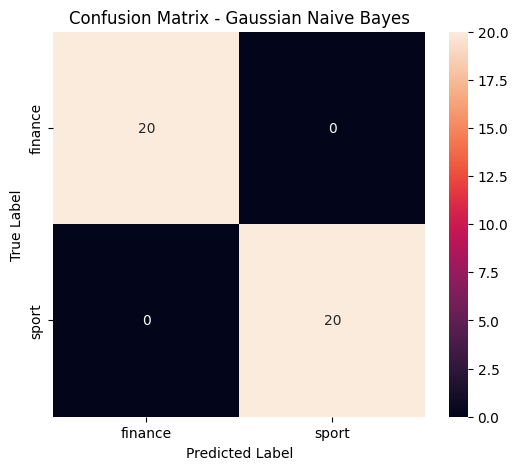

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["finance", "sport"],
    yticklabels=["finance", "sport"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Gaussian Naive Bayes")

plt.show()

Kode tersebut digunakan untuk menampilkan hasil evaluasi model Gaussian Naive Bayes dalam bentuk tabel yang terdiri dari **Accuracy, Precision, Recall, dan F1-Score**. Berdasarkan output, seluruh metrik memiliki nilai **1,0 atau 100%**. Hal ini menunjukkan bahwa pada data pengujian, seluruh data berhasil diklasifikasikan dengan benar dan tidak terdapat kesalahan prediksi. Nilai Precision dan Recall sebesar 1,0 juga menunjukkan bahwa model mampu menghasilkan prediksi yang tepat sekaligus mengenali seluruh data dari masing-masing kelas.



In [ ]:
hasil_evaluasi = pd.DataFrame({
    "Metrik": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Nilai": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

display(hasil_evaluasi)

,Metrik,Nilai
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1-Score,1.0


Kode tersebut digunakan untuk menampilkan **hasil tahapan preprocessing teks** dengan memilih kolom `id`, `isi_berita`, `label`, `clean_text`, `tokens_stopword`, dan `tokens_stemmed`. Fungsi `head(10)` menampilkan 10 data pertama untuk melihat perubahan teks pada setiap tahap preprocessing. Berdasarkan output, teks berita awal pada kolom `isi_berita` telah melalui proses **cleaning** pada `clean_text`, kemudian kata-kata yang tidak diperlukan telah dihilangkan melalui **stopword removal** pada `tokens_stopword`, dan selanjutnya kata-kata telah diubah ke bentuk dasarnya melalui **stemming** pada `tokens_stemmed`. Contohnya, kata *pacuan* berubah menjadi *pacu*, *diarahkan* menjadi *arah*, dan *dukungan* menjadi *dukung*. Hasil ini menunjukkan bahwa proses preprocessing telah mengubah teks mentah menjadi data yang lebih terstruktur dan siap digunakan pada tahap ekstraksi fitur dan klasifikasi.


In [ ]:
hasil_preprocessing = df[[
    "id",
    "isi_berita",
    "label",
    "clean_text",
    "tokens_stopword",
    "tokens_stemmed"
]]

display(hasil_preprocessing.head(10))

,id,isi_berita,label,clean_text,tokens_stopword,tokens_stemmed
0,1,Pacuan kuda Indonesia mulai diarahkan menuju p...,sport,pacuan kuda indonesia mulai diarahkan menuju p...,"[pacuan, kuda, indonesia, mulai, diarahkan, me...","[pacu, kuda, indonesia, mulai, arah, tuju, pan..."
1,2,"Jelang Asian Games 2026, dukungan untuk 432 at...",sport,jelang asian games dukungan untuk atlet indone...,"[jelang, asian, games, dukungan, atlet, indone...","[jelang, asi, games, dukung, atlet, indonesia,..."
2,3,Nova Widianto mulai menangani tim ganda campur...,sport,nova widianto mulai menangani tim ganda campur...,"[nova, widianto, mulai, menangani, tim, ganda,...","[nova, widianto, mulai, tangan, tim, ganda, ca..."
3,4,Timnas basket putra Indonesia jadi rombongan p...,sport,timnas basket putra indonesia jadi rombongan p...,"[timnas, basket, putra, indonesia, jadi, rombo...","[timnas, basket, putra, indonesia, jadi, rombo..."
4,5,"Bagi pelari urban, lari kini bukan lagi sekada...",sport,bagi pelari urban lari kini bukan lagi sekadar...,"[pelari, urban, lari, kini, bukan, sekadar, me...","[lari, urban, lari, kini, bukan, sekadar, keja..."
5,6,Pelatih Timnas basket putra Indonesia David Si...,sport,pelatih timnas basket putra indonesia david si...,"[pelatih, timnas, basket, putra, indonesia, da...","[latih, timnas, basket, putra, indonesia, davi..."
6,7,Putri Kusuma Wardani percaya diri dengan kompo...,sport,putri kusuma wardani percaya diri dengan kompo...,"[putri, kusuma, wardani, percaya, diri, kompos...","[putri, kusuma, wardani, percaya, diri, kompos..."
7,8,Momen debut di Asian Games 2026 tak mau disia-...,sport,momen debut di asian games tak mau disiasiakan...,"[momen, debut, asian, games, tak, mau, disiasi...","[momen, debut, asi, games, tak, mau, disiasiak..."
8,9,Pupus sudah harapan Sean Gelael dan rekan-reka...,sport,pupus sudah harapan sean gelael dan rekanrekan...,"[pupus, harapan, sean, gelael, rekanrekannya, ...","[pupus, harap, sean, gelael, rekanrekannya, te..."
9,10,Liga Jasa Keuangan (LJK) yang lebih dikenal de...,sport,liga jasa keuangan ljk yang lebih dikenal deng...,"[liga, jasa, keuangan, ljk, lebih, dikenal, ko...","[liga, jasa, uang, ljk, lebih, kenal, kompetis..."


Kode tersebut digunakan untuk **mengekspor hasil preprocessing teks ke dalam file Excel**. Data yang dipilih meliputi teks berita asli, label, serta hasil dari setiap tahapan preprocessing seperti *case folding*, penghapusan tanda baca dan angka, *cleaning*, *stopword removal*, dan *stemming*. Karena `tokens_stopword` dan `tokens_stemmed` masih berbentuk daftar kata (*list*), keduanya diubah menjadi teks menggunakan `" ".join(x)` agar lebih mudah dibaca di Excel. Selanjutnya, hasil tersebut disimpan dalam file **`hasil_preprocessing.xlsx`** tanpa menyertakan index DataFrame. Dengan demikian, kode ini berfungsi sebagai **dokumentasi dan penyimpanan hasil akhir preprocessing**, bukan sebagai proses preprocessing itu sendiri.


In [75]:
hasil_export = df[[
    "id",
    "isi_berita",
    "label",
    "case_folding",
    "tanpa_tanda_baca",
    "tanpa_angka",
    "clean_text",
    "tokens_stopword",
    "tokens_stemmed"
]].copy()

# Mengubah list token menjadi teks
hasil_export["tokens_stopword"] = hasil_export["tokens_stopword"].apply(
    lambda x: " ".join(x)
)

hasil_export["tokens_stemmed"] = hasil_export["tokens_stemmed"].apply(
    lambda x: " ".join(x)
)

# Menyimpan hasil preprocessing ke file Excel
hasil_export.to_excel(
    "hasil_preprocessing.xlsx",
    index=False
)

print("File berhasil disimpan sebagai:")
print("hasil_preprocessing.xlsx")

File berhasil disimpan sebagai:
hasil_preprocessing.xlsx
